# Code to train model on recognizing different hand signs.

In [1]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm
import os
MAIN_DIR = os.path.dirname(os.path.abspath('__file__'))

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import timm

In [2]:
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {DEVICE} device")

Using cuda device


# Dataset Generation

In [3]:
#load data
data_dict = pickle.load(open('data.p', 'rb'))

data = data_dict['data']
labels = data_dict['labels']

In [4]:
print(data[0])

[[0.035514235496520996, 0.22223418951034546], [0.11169832944869995, 0.19448411464691162], [0.16484075784683228, 0.11388331651687622], [0.18486648797988892, 0.04538530111312866], [0.21560907363891602, 0.00535130500793457], [0.11942976713180542, 0.01025015115737915], [0.1642586588859558, 0.002783656120300293], [0.14887046813964844, 0.07327735424041748], [0.12794345617294312, 0.07383805513381958], [0.08103382587432861, 0.00112837553024292], [0.13206630945205688, 0.0], [0.11622905731201172, 0.0828583836555481], [0.09257596731185913, 0.07449668645858765], [0.04280579090118408, 0.005159914493560791], [0.09071874618530273, 0.0011982321739196777], [0.0796588659286499, 0.0828818678855896], [0.05300915241241455, 0.07901966571807861], [0.0, 0.01544189453125], [0.04613137245178223, 0.012677490711212158], [0.046126604080200195, 0.07027322053909302], [0.02311640977859497, 0.0739791989326477]]


In [5]:
class SignDataset(Dataset):
    def __init__(self, data, labels):
        self.data = [torch.tensor(seq, dtype=torch.float32).flatten() for seq in data]
        self.labels = torch.tensor([int(label) for label in labels], dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

    @property
    def classes(self):
        return self.data.classes

In [6]:
dataset = SignDataset(data, labels)
len(dataset)

1760

In [7]:
landmarks, label = dataset[1000]
print(landmarks)
print(label)

tensor([0.0000, 0.1394, 0.0180, 0.0942, 0.0489, 0.0701, 0.0755, 0.0659, 0.0955,
        0.0688, 0.0643, 0.0603, 0.1084, 0.0362, 0.1368, 0.0172, 0.1580, 0.0000,
        0.0698, 0.0727, 0.1182, 0.0458, 0.1498, 0.0228, 0.1748, 0.0018, 0.0744,
        0.0935, 0.1216, 0.0664, 0.1502, 0.0455, 0.1720, 0.0265, 0.0777, 0.1210,
        0.1154, 0.0999, 0.1367, 0.0825, 0.1543, 0.0661])
tensor(27)


In [8]:
#Split train and validation dataset
train_dataset, test_dataset = random_split(dataset, [0.8, 0.2])
print(len(train_dataset))
print(len(test_dataset))

1408
352


# DataLoader Generation

In [9]:
train_dataloader = DataLoader(dataset, batch_size = 128, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = 64, shuffle = True)

In [10]:
for data, label in train_dataloader:
    break

In [11]:
# 128 datapoints per batch, 21 landmarks [x, y] flatten to become shape 42
# Roughly 10 batches per epoch for training data
print(data.shape)

torch.Size([128, 42])


In [12]:
print(label.shape)

torch.Size([128])


# Neural Network Construction

In [13]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2*21, 100),
            nn.ReLU(),
            nn.Linear(100, 160),
            nn.ReLU(),
            nn.Linear(160, 26),
            nn.LogSoftmax(dim = 1)
        )

    def forward(self, x):
        return self.net(x)

In [14]:
model = NeuralNetwork()
print(model)

NeuralNetwork(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=160, bias=True)
    (3): ReLU()
    (4): Linear(in_features=160, out_features=26, bias=True)
    (5): LogSoftmax(dim=1)
  )
)


In [15]:
ex_output = model(data)
ex_output.shape # [batch_size, num_classes]

torch.Size([128, 26])

# Loss & Optimizer

In [16]:
#Loss
criterion = nn.CrossEntropyLoss()
#Optimizer
optimizer = optim.Adam(model.parameters(), lr = 0.001)

criterion(ex_output, label)

In [17]:
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Load Pre-trained Model

In [18]:
def load_checkpoint(filename: str, model: object, optimizer: object) -> (object, object): 
    print("Loading checkpoint")
    checkpoint = torch.load(filename)
    model.load_state_dict(checkpoint['state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    #If save more things, get more from the dict and then return
    return model, optimizer

In [19]:
model, optimizer = load_checkpoint("model_checkpoint_2_1.pth.rar", model, optimizer)

Loading checkpoint


In [20]:
model

NeuralNetwork(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=160, bias=True)
    (3): ReLU()
    (4): Linear(in_features=160, out_features=26, bias=True)
    (5): LogSoftmax(dim=1)
  )
)

In [21]:
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Update Classification Classes 26 -> 29

In [22]:
old_linear_nn_model = model.net[4]
in_features = old_linear_nn_model.in_features

print(old_linear_nn_model)
print(in_features)

Linear(in_features=160, out_features=26, bias=True)
160


In [23]:
new_linear_nn_model = nn.Linear(in_features, 29)
print(new_linear_nn_model)

Linear(in_features=160, out_features=29, bias=True)


In [24]:
# copy the old weights (for the first 26 classes)
with torch.no_grad():
    new_linear_nn_model.weight[:26] = old_linear_nn_model.weight
    new_linear_nn_model.bias[:26] = old_linear_nn_model.bias

In [25]:
print(new_linear_nn_model.weight[27])

tensor([-0.0286, -0.0152,  0.0438, -0.0217, -0.0503, -0.0702,  0.0393,  0.0149,
        -0.0219,  0.0426,  0.0619,  0.0696,  0.0098, -0.0329, -0.0634, -0.0619,
        -0.0755,  0.0662,  0.0214, -0.0190, -0.0654, -0.0745, -0.0362, -0.0534,
         0.0634,  0.0087,  0.0775, -0.0607, -0.0723, -0.0773,  0.0629,  0.0594,
         0.0425, -0.0054,  0.0548,  0.0113,  0.0118,  0.0122,  0.0573, -0.0583,
         0.0032, -0.0193, -0.0323, -0.0247, -0.0390,  0.0012,  0.0538,  0.0318,
        -0.0103,  0.0270, -0.0504,  0.0033,  0.0551, -0.0053,  0.0219,  0.0192,
        -0.0718, -0.0149,  0.0754, -0.0700,  0.0223, -0.0483, -0.0063, -0.0381,
        -0.0224,  0.0180,  0.0017, -0.0133, -0.0116,  0.0471,  0.0397, -0.0525,
         0.0759,  0.0418,  0.0604,  0.0324,  0.0128,  0.0333,  0.0426, -0.0457,
         0.0484,  0.0524,  0.0274,  0.0046,  0.0285, -0.0203, -0.0716, -0.0303,
        -0.0148, -0.0345,  0.0563, -0.0182,  0.0320, -0.0507, -0.0038, -0.0240,
         0.0717, -0.0332, -0.0736, -0.01

In [26]:
model.net[4] = new_linear_nn_model

model

NeuralNetwork(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=160, bias=True)
    (3): ReLU()
    (4): Linear(in_features=160, out_features=29, bias=True)
    (5): LogSoftmax(dim=1)
  )
)

# Freezed layer won't be updated during training
# Probably not neccessary for ratio of new data and old data < 10 : 1
for param in model.parameters():
    param.requires_grad = False  # freeze everything

model.net[4].weight.requires_grad = True  # unfreeze full output layer
model.net[4].bias.requires_grad = True

def mask_old_class_grads(grad):
    mask = torch.zeros_like(grad)
    mask[26:] = 1  # Allow gradient flow only to classes 26–28
    return grad * mask

model.net[4].weight.register_hook(mask_old_class_grads)
model.net[4].bias.register_hook(mask_old_class_grads)

# Update optimizer 26 -> 29

In [28]:
# Using a new optimizer since clssifcation classes change from 26 to 29
new_params = filter(lambda p: p.requires_grad, model.parameters())
optimizer = torch.optim.Adam(new_params, lr=1e-4)

# Continue Model Training

In [29]:
num_epochs = 400
train_losses, val_losses = [], []

model.to(DEVICE)

for epoch in range(num_epochs):
    model.train() #setting model mode .train or .eval
    running_loss = 0.0
    for landmarks, labels in tqdm(train_dataloader, desc = "Training loop"):
        landmarks, labels = landmarks.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(landmarks)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    train_loss = running_loss / len(train_dataloader.dataset)
    train_losses.append(train_loss)

    #Validation phase
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for landmarks, labels in tqdm(test_dataloader, desc = "Validation loop"):
            landmarks, labels = landmarks.to(DEVICE), labels.to(DEVICE)
            outputs = model(landmarks)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * labels.size(0)
    val_loss = running_loss / len(test_dataloader.dataset)
    val_losses.append(val_loss)

    print("Epoch %d out of %s - Train loss: %s , Validation loss: %s" % (epoch + 1, num_epochs, train_loss, val_loss))

Training loop:   0%|          | 0/14 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 1 out of 400 - Train loss: 10.811065535111862 , Validation loss: 9.66965371912176


Training loop:   0%|          | 0/14 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/6 [00:00<?, ?it/s]

...

Validation loop:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 399 out of 400 - Train loss: 0.023674039813605222 , Validation loss: 0.018899818882346153


Training loop:   0%|          | 0/14 [00:00<?, ?it/s]

Validation loop:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 400 out of 400 - Train loss: 0.023652428354729305 , Validation loss: 0.0188330506736582


# Visualize

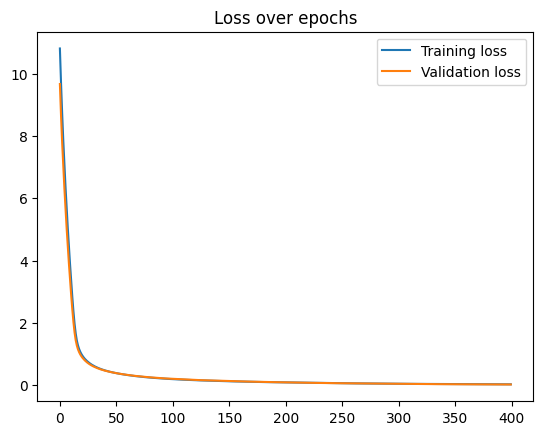

In [30]:
plt.plot(train_losses, label='Training loss')
plt.plot(val_losses, label='Validation loss')
plt.legend()
plt.title("Loss over epochs")
plt.show()

# Save Model State for Further Training Later

In [31]:
checkpoint = {'state_dict' : model. state_dict(), 'optimizer': optimizer.state_dict()}

In [32]:
def save_checkpoint(state, filename = "model_checkpoint_3.pth.rar"):
    print("Saving current checkpoint")
    torch.save(state, filename)

In [33]:
save_checkpoint(checkpoint)

Saving current checkpoint


In [40]:
import mlflow.pytorch

with mlflow.start_run():
    mlflow.pytorch.log_model(model, "model")

2025/05/29 18:56:41 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.0+cu118) contains a local version label (+cu118). MLflow logged a pip requirement for this package as 'torch==2.7.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/05/29 18:56:57 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.0+cu118) contains a local version label (+cu118). MLflow logged a pip requirement for this package as 'torch==2.7.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/05/29 18:56:57 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


# Save Model for inferencing

In [34]:
# Save model for model inference
# Save the model's state_dict
model_scripted = torch.jit.script(model) # Export to TorchScript
model_scripted.save('model_3.pth.rar') # Save

# Test Trained model

In [35]:
import mediapipe as mp
import cv2

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

hands = mp_hands.Hands(static_image_mode=True, min_detection_confidence=0.6, max_num_hands = 1)

In [36]:
def predict(model, input_landmarks):
    model.eval()
    with torch.no_grad():
        input_landmarks = torch.tensor(input_landmarks, dtype=torch.float32).flatten()
        input_landmarks = input_landmarks.unsqueeze(0).to(DEVICE)
        predictions_log = model(input_landmarks)
        predictions_prob = torch.exp(predictions_log)
        max_probability_predicted, max_probability_index = torch.max(predictions_prob, dim=1)
    return max_probability_index.item()

In [37]:
def hand_landmarks_detection(path: str) -> list:
    data_aux, x_, y_ = [], [], []

    img = cv2.imread(path)
    # Flip image horizontally to correctly identify left hand being used in the collected images
    #img = cv2.flip(img, 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)

    # Only use the images with left hand for dataset generation => only 21 points for landmarks
    if results.multi_hand_landmarks and results.multi_handedness[0].classification[0].label == 'Left':
        for hand_landmarks in results.multi_hand_landmarks:
            # Write images with overlapped hand landmarks on the original data collected.
            mp_drawing.draw_landmarks(
                img,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS,  
                mp_drawing_styles.get_default_hand_landmarks_style(),
                mp_drawing_styles.get_default_hand_connections_style())
            
            for i in range(len(hand_landmarks.landmark)):
                x = hand_landmarks.landmark[i].x
                y = hand_landmarks.landmark[i].y

                x_.append(x)
                y_.append(y)

        # To reduce variability for different positions of the hand on the screen, each data point subtracts the lowest x and y position per frame.
        # Essentially reducing the positions of all landmarks to be start at the bottom left conner of the image.
        for i in range(len(hand_landmarks.landmark)):
            x = hand_landmarks.landmark[i].x
            y = hand_landmarks.landmark[i].y
            data_aux.append([x - min(x_), y - min(y_)])
    return data_aux
        

In [38]:
test_folder = "neural_net_model_test_set_after_ver3"
counter = correct_points = 0
for char_folder in os.listdir(test_folder):
    correct_result = char_folder
    for pic in os.listdir(os.path.join(test_folder, char_folder)):
        hand_landmarks = hand_landmarks_detection(os.path.join(test_folder, char_folder, pic))
        if hand_landmarks:
            counter += 1
            predicted_result = predict(model, hand_landmarks)
            if str(predicted_result) == char_folder:
                correct_points += 1

print(counter)
print(correct_points)
print("Accuracy: " + str(correct_points/counter))
        

242
233
Accuracy: 0.9628099173553719
